# Result Comparison: Classical ML vs Variational Quantum Classifier

**Experimental setup:** All models trained on the same **3 413-epoch training set** and evaluated on the same **925-epoch held-out test set** (8 unseen subjects). EEG features: Frontal Theta/Beta Ratio, Frontal Theta Power, Central Beta Power, Frontal Beta2 Power, Spectral Entropy.

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')

# ── Colour palette ───────────────────────────────────────────────────────
PALETTE = {
    'VQC':                 '#9B59B6',
    'Logistic Regression': '#4C72B0',
    'SVM (RBF)':           '#DD8452',
    'Random Forest':       '#55A868',
    'XGBoost':             '#C44E52',
}
MODEL_ORDER = [
    'VQC', 'Logistic Regression', 'SVM (RBF)', 'Random Forest', 'XGBoost'
]

# ── Epoch-level metrics ──────────────────────────────────────────────────
RESULTS = {
    'VQC':                 dict(Accuracy=0.6195, Precision=0.3660, Recall=0.5726, F1=0.4465, AUC=0.6227),
    'Logistic Regression': dict(Accuracy=0.397,  Precision=0.261,  Recall=0.698,  F1=0.380,  AUC=0.522),
    'SVM (RBF)':           dict(Accuracy=0.685,  Precision=0.420,  Recall=0.609,  F1=0.496,  AUC=0.698),
    'Random Forest':       dict(Accuracy=0.665,  Precision=0.418,  Recall=0.690,  F1=0.520,  AUC=0.711),
    'XGBoost':             dict(Accuracy=0.694,  Precision=0.477,  Recall=0.387,  F1=0.426,  AUC=0.653),
}

# ── Recording-level (majority vote) ──────────────────────────────────────
REC_RESULTS = {
    'VQC':                 dict(Accuracy=0.688, F1=0.667),
    'Logistic Regression': dict(Accuracy=0.562, F1=0.462),
    'SVM (RBF)':           dict(Accuracy=0.750, F1=0.667),
    'Random Forest':       dict(Accuracy=0.812, F1=0.762),
    'XGBoost':             dict(Accuracy=0.688, F1=0.615),
}

# ── Per-class breakdown (Prec/Rec/F1 for Rest and Mental Math) ───────────
# Columns: Prec(Rest), Rec(Rest), F1(Rest), Prec(Math), Rec(Math), F1(Math)
PC_RESULTS = {
    'VQC':                 (0.803, 0.637, 0.710, 0.366, 0.573, 0.447),
    'Logistic Regression': (0.730, 0.483, 0.580, 0.261, 0.698, 0.380),
    'SVM (RBF)':           (0.775, 0.722, 0.748, 0.420, 0.609, 0.496),
    'Random Forest':       (0.769, 0.698, 0.732, 0.418, 0.690, 0.520),
    'XGBoost':             (0.778, 0.790, 0.784, 0.477, 0.387, 0.426),
}

df = pd.DataFrame(RESULTS).T.loc[MODEL_ORDER]
print('Results loaded for:', list(RESULTS.keys()))
print(f'Test set: 925 epochs  |  rest=677  mental=248  |  8 subjects')

Results loaded for: ['VQC', 'Logistic Regression', 'SVM (RBF)', 'Random Forest', 'XGBoost']
Test set: 925 epochs  |  rest=677  mental=248  |  8 subjects


## 1. Overall Epoch-Level Metrics

In [3]:
styled = (
    df.style
    .format('{:.3f}')
    .background_gradient(cmap='YlGn', subset=['F1', 'AUC'])
    .highlight_max(subset=df.columns.tolist(), color='#A9DFBF')
    .highlight_min(subset=df.columns.tolist(), color='#FADBD8')
    .set_caption(
        'Epoch-level metrics  |  train=3 413  test=925  |  8 unseen subjects  |  '
        'Green = best, Red = worst per column'
    )
)
display(styled)

,Accuracy,Precision,Recall,F1,AUC
VQC,0.620,0.366,0.573,0.447,0.623
Logistic Regression,0.397,0.261,0.698,0.380,0.522
SVM (RBF),0.685,0.420,0.609,0.496,0.698
Random Forest,0.665,0.418,0.690,0.520,0.711
XGBoost,0.694,0.477,0.387,0.426,0.653


## 2. Metric Comparison

F1 and AUC-ROC are the primary metrics for this imbalanced task (rest:mental ≈ 3:1). Accuracy alone is misleading — a model predicting *Rest* for every epoch achieves 73% accuracy with 0% mental-math recall.

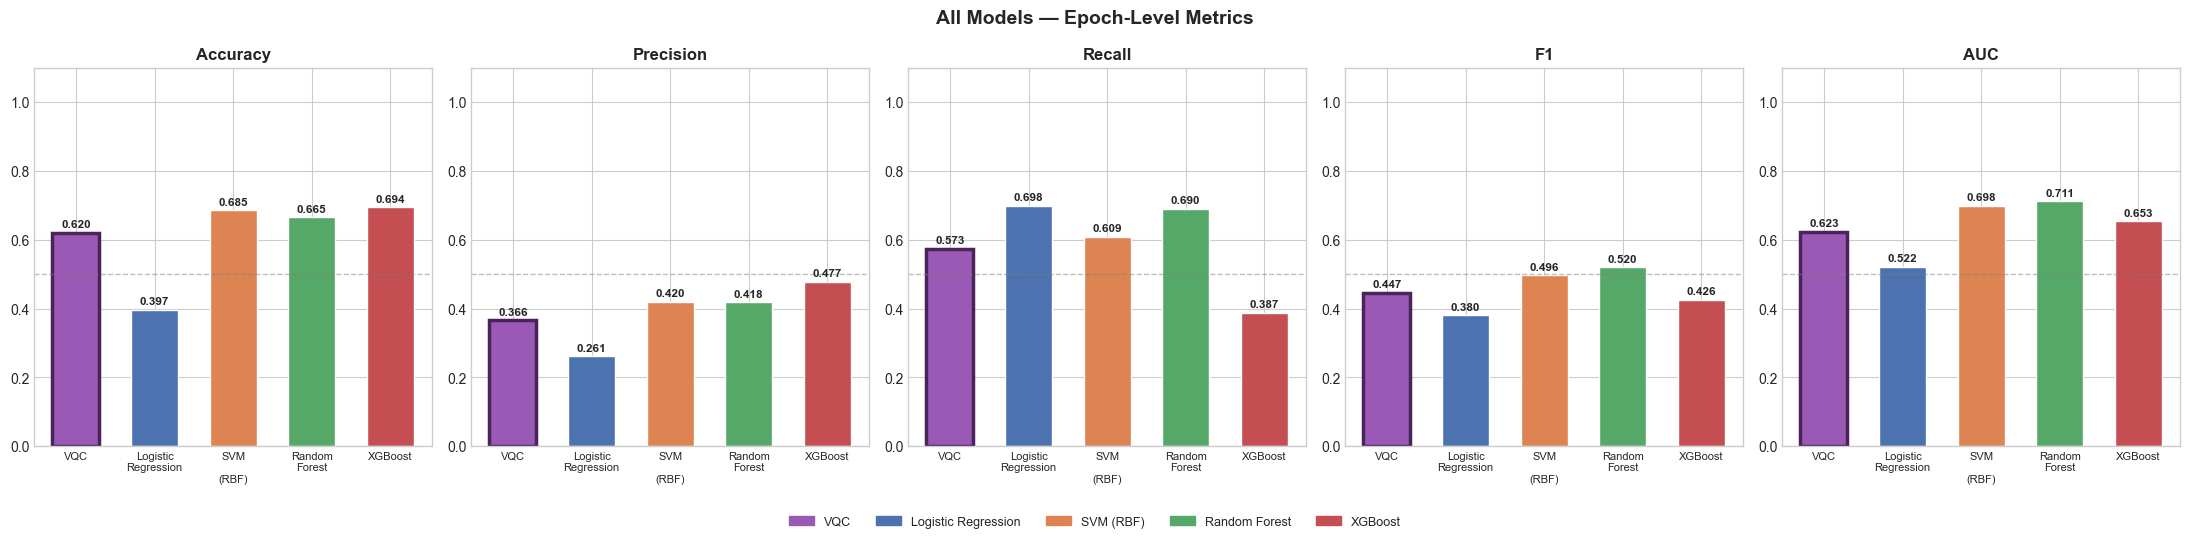

In [4]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
names   = df.index.tolist()
colors  = [PALETTE[n] for n in names]
x       = np.arange(len(names))

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
for ax, metric in zip(axes, metrics):
    vals = df[metric].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', width=0.6)
    vqc_i = names.index('VQC')
    bars[vqc_i].set_edgecolor('#4A235A'); bars[vqc_i].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n').replace('(', '\n(') for n in names],
                       fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(metric, fontsize=12, fontweight='bold')

handles = [mpatches.Patch(color=PALETTE[n], label=n) for n in names]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.08))
plt.suptitle('All Models — Epoch-Level Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Radar Chart — Full Profile

The radar chart gives a holistic view of each model's strengths and weaknesses across all five metrics simultaneously.

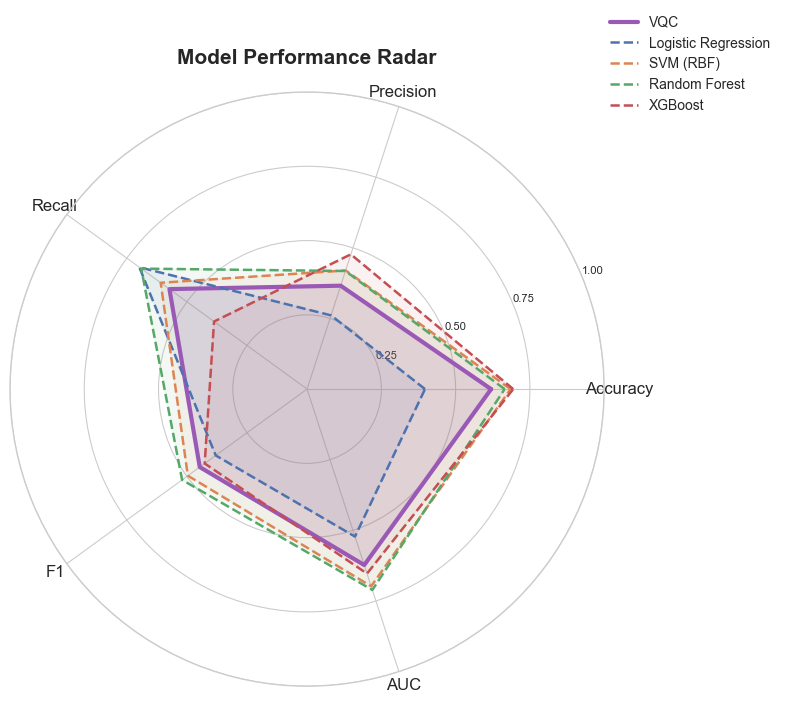

In [5]:
metrics_r = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
N_r = len(metrics_r)
angles = np.linspace(0, 2 * np.pi, N_r, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name in MODEL_ORDER:
    vals = [RESULTS[name][m] for m in metrics_r] + [RESULTS[name][metrics_r[0]]]
    col  = PALETTE[name]
    lw   = 3.0 if name == 'VQC' else 1.8
    ls   = '-' if name == 'VQC' else '--'
    ax.plot(angles, vals, color=col, lw=lw, ls=ls, label=name)
    ax.fill(angles, vals, color=col, alpha=0.07 if name != 'VQC' else 0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_r, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Model Performance Radar', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

## 4. AUC-ROC Comparison

AUC-ROC is threshold-independent and measures the model's ability to rank mental-math epochs above rest epochs. Random classifier = 0.5.

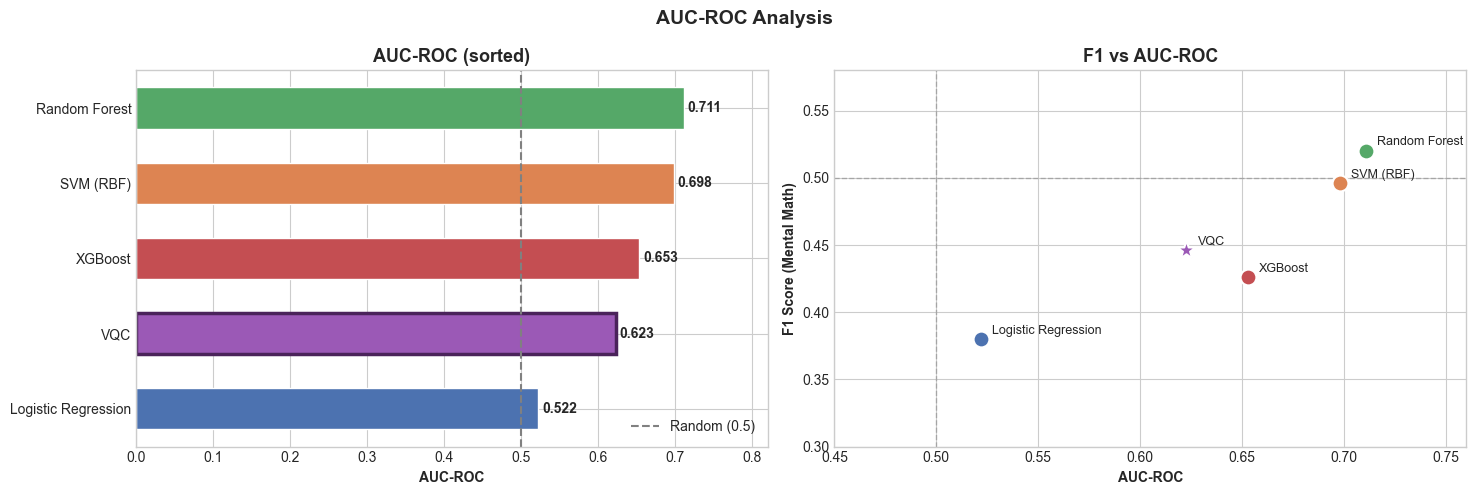

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: AUC horizontal bar chart
ax = axes[0]
sorted_names = sorted(MODEL_ORDER, key=lambda n: RESULTS[n]['AUC'])
sorted_aucs  = [RESULTS[n]['AUC'] for n in sorted_names]
sorted_cols  = [PALETTE[n] for n in sorted_names]
bars = ax.barh(sorted_names, sorted_aucs, color=sorted_cols, edgecolor='white', height=0.55)
vqc_i = sorted_names.index('VQC')
bars[vqc_i].set_edgecolor('#4A235A'); bars[vqc_i].set_linewidth(2.5)
for bar, val in zip(bars, sorted_aucs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax.axvline(0.5, color='grey', ls='--', lw=1.5, label='Random (0.5)')
ax.set_xlim(0, 0.82)
ax.set_xlabel('AUC-ROC', fontweight='bold')
ax.set_title('AUC-ROC (sorted)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Right: F1 vs AUC scatter
ax2 = axes[1]
for name in MODEL_ORDER:
    f1  = RESULTS[name]['F1']
    auc = RESULTS[name]['AUC']
    col = PALETTE[name]
    ms  = 200 if name == 'VQC' else 130
    mk  = '*' if name == 'VQC' else 'o'
    ax2.scatter(auc, f1, color=col, s=ms, marker=mk, zorder=5,
               edgecolors='white', linewidths=1.5)
    ax2.annotate(name, (auc, f1),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax2.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.5)
ax2.axvline(0.5, color='grey', ls='--', lw=1, alpha=0.5)
ax2.set_xlabel('AUC-ROC', fontweight='bold')
ax2.set_ylabel('F1 Score (Mental Math)', fontweight='bold')
ax2.set_title('F1 vs AUC-ROC', fontsize=13, fontweight='bold')
ax2.set_xlim(0.45, 0.76); ax2.set_ylim(0.3, 0.58)

plt.suptitle('AUC-ROC Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Per-Class Breakdown

The minority class (Mental Math, 27% of test set) is substantially harder. All models achieve higher precision and recall on Rest than on Mental Math.

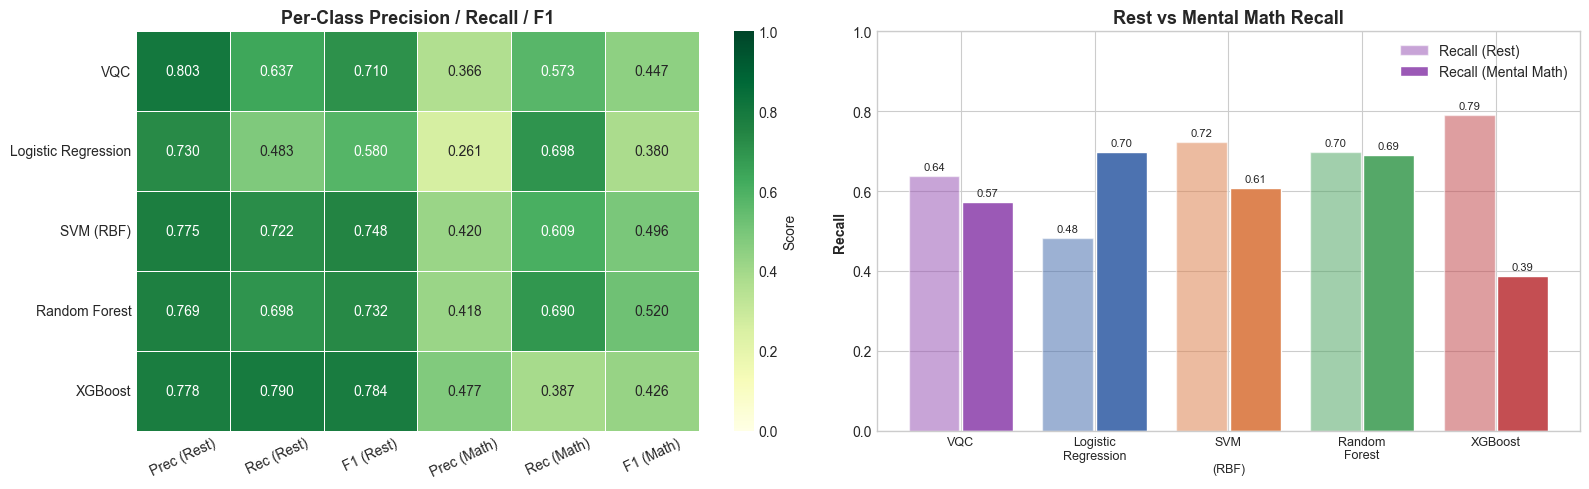

In [7]:
cols = ['Prec (Rest)', 'Rec (Rest)', 'F1 (Rest)',
        'Prec (Math)', 'Rec (Math)', 'F1 (Math)']
pc_df = pd.DataFrame(
    {name: dict(zip(cols, vals)) for name, vals in PC_RESULTS.items()}
).T.loc[MODEL_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Score'})
axes[0].set_title('Per-Class Precision / Recall / F1', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)

# Recall comparison: Rest vs Mental Math
ax2 = axes[1]
x = np.arange(len(MODEL_ORDER))
rec_rest = [PC_RESULTS[n][1] for n in MODEL_ORDER]
rec_math = [PC_RESULTS[n][4] for n in MODEL_ORDER]
cols_bar = [PALETTE[n] for n in MODEL_ORDER]
b1 = ax2.bar(x - 0.2, rec_rest, 0.38, label='Recall (Rest)',
             color=cols_bar, alpha=0.55, edgecolor='white')
b2 = ax2.bar(x + 0.2, rec_math, 0.38, label='Recall (Mental Math)',
             color=cols_bar, alpha=1.0, edgecolor='white')
for bar, val in [*zip(b1, rec_rest), *zip(b2, rec_math)]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels([n.replace(' ', '\n').replace('(', '\n(') for n in MODEL_ORDER],
                    fontsize=9)
ax2.set_ylim(0, 1.0); ax2.set_ylabel('Recall', fontweight='bold')
ax2.set_title('Rest vs Mental Math Recall', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 6. Recording-Level Majority Voting (Classical Models)

Each test recording (subject × condition) is classified by majority vote over its epochs. This mirrors the real deployment scenario — one cognitive load decision per session.

,Accuracy,F1
VQC,0.688,0.667
Logistic Regression,0.562,0.462
SVM (RBF),0.750,0.667
Random Forest,0.812,0.762
XGBoost,0.688,0.615


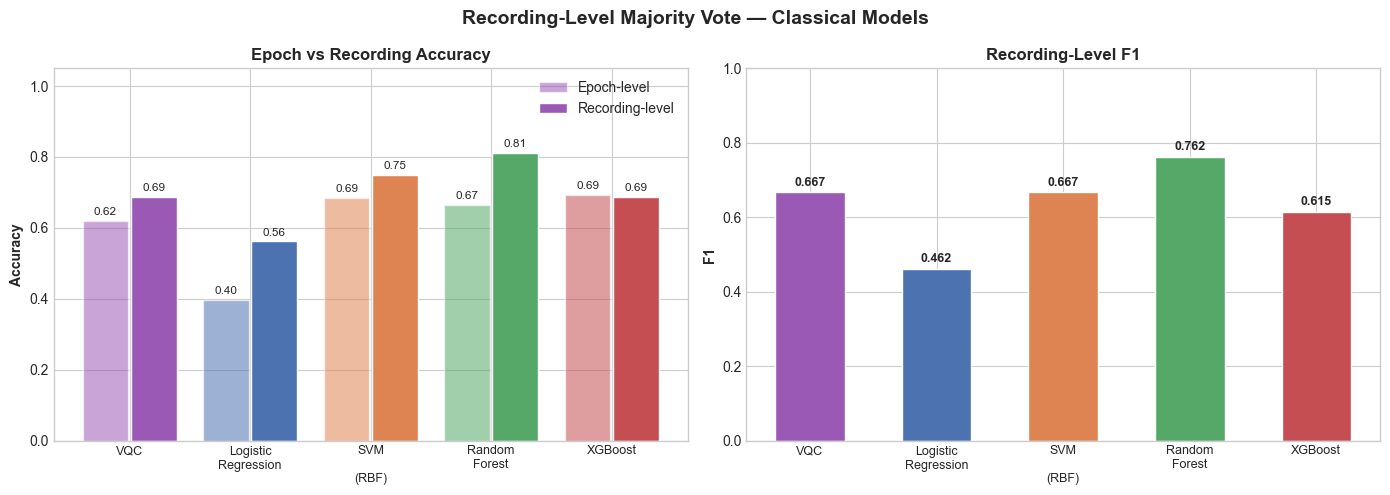

In [9]:
rec_df = pd.DataFrame(REC_RESULTS).T
classical_order = ['VQC', 'Logistic Regression', 'SVM (RBF)', 'Random Forest', 'XGBoost']
rec_df = rec_df.loc[classical_order]
epoch_accs = [RESULTS[n]['Accuracy'] for n in classical_order]

display(
    rec_df.style
    .format('{:.3f}')
    .background_gradient(cmap='YlGn')
    .highlight_max(color='#A9DFBF')
    .set_caption('Recording-level results (majority vote per subject/condition)')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(classical_order))
rcols = [PALETTE[n] for n in classical_order]

# Epoch vs Recording Accuracy
b1 = axes[0].bar(x - 0.2, epoch_accs,              0.38, color=rcols, alpha=0.55,
                 edgecolor='white', label='Epoch-level')
b2 = axes[0].bar(x + 0.2, rec_df['Accuracy'].values, 0.38, color=rcols, alpha=1.0,
                 edgecolor='white', label='Recording-level')
for bar, val in [*zip(b1, epoch_accs), *zip(b2, rec_df['Accuracy'].values)]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ', '\n').replace('(', '\n(') for n in classical_order],
                         fontsize=9)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Epoch vs Recording Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Recording-level F1
rec_f1 = rec_df['F1'].values
bars = axes[1].bar(x, rec_f1, color=rcols, edgecolor='white', width=0.55)
for bar, val in zip(bars, rec_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ', '\n').replace('(', '\n(') for n in classical_order],
                          fontsize=9)
axes[1].set_ylim(0, 1.0); axes[1].set_ylabel('F1', fontweight='bold')
axes[1].set_title('Recording-Level F1', fontsize=12, fontweight='bold')

plt.suptitle('Recording-Level Majority Vote — Classical Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Precision–Recall Tradeoff (Mental Math)

High recall means fewer missed mental-load states (safety-critical). High precision means fewer false alarms. The ideal model sits in the top-right corner.

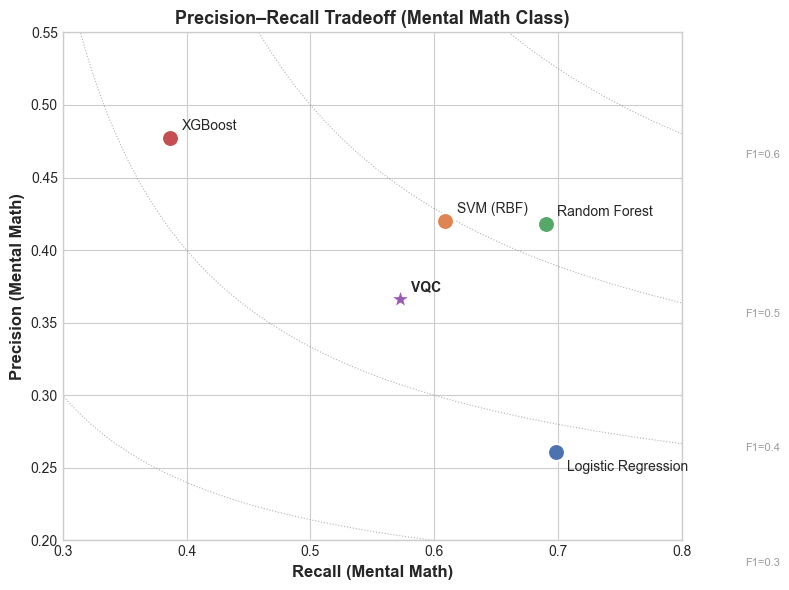

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for name in MODEL_ORDER:
    prec = RESULTS[name]['Precision']
    rec  = RESULTS[name]['Recall']
    col  = PALETTE[name]
    ms   = 250 if name == 'VQC' else 150
    mk   = '*' if name == 'VQC' else 'o'
    ax.scatter(rec, prec, color=col, s=ms, marker=mk, zorder=5,
               edgecolors='white', linewidths=1.5)
    offset = (8, 6) if name != 'Logistic Regression' else (8, -14)
    ax.annotate(name, (rec, prec), textcoords='offset points',
                xytext=offset, fontsize=10, fontweight='bold' if name == 'VQC' else 'normal')

# F1 iso-lines
r_range = np.linspace(0.01, 1.0, 200)
for f1_target in [0.3, 0.4, 0.5, 0.6]:
    p_line = f1_target * r_range / (2 * r_range - f1_target)
    mask   = (p_line > 0) & (p_line <= 1)
    ax.plot(r_range[mask], p_line[mask], 'grey', lw=0.8, ls=':', alpha=0.6)
    idx = np.searchsorted(r_range[mask], 0.85)
    if idx < mask.sum():
        ax.text(r_range[mask][idx], p_line[mask][idx],
                f'F1={f1_target:.1f}', fontsize=8, color='grey', alpha=0.8)

ax.set_xlabel('Recall (Mental Math)', fontweight='bold', fontsize=12)
ax.set_ylabel('Precision (Mental Math)', fontweight='bold', fontsize=12)
ax.set_title('Precision–Recall Tradeoff (Mental Math Class)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.3, 0.8); ax.set_ylim(0.2, 0.55)
plt.tight_layout()
plt.show()

## 8. Summary Dashboard

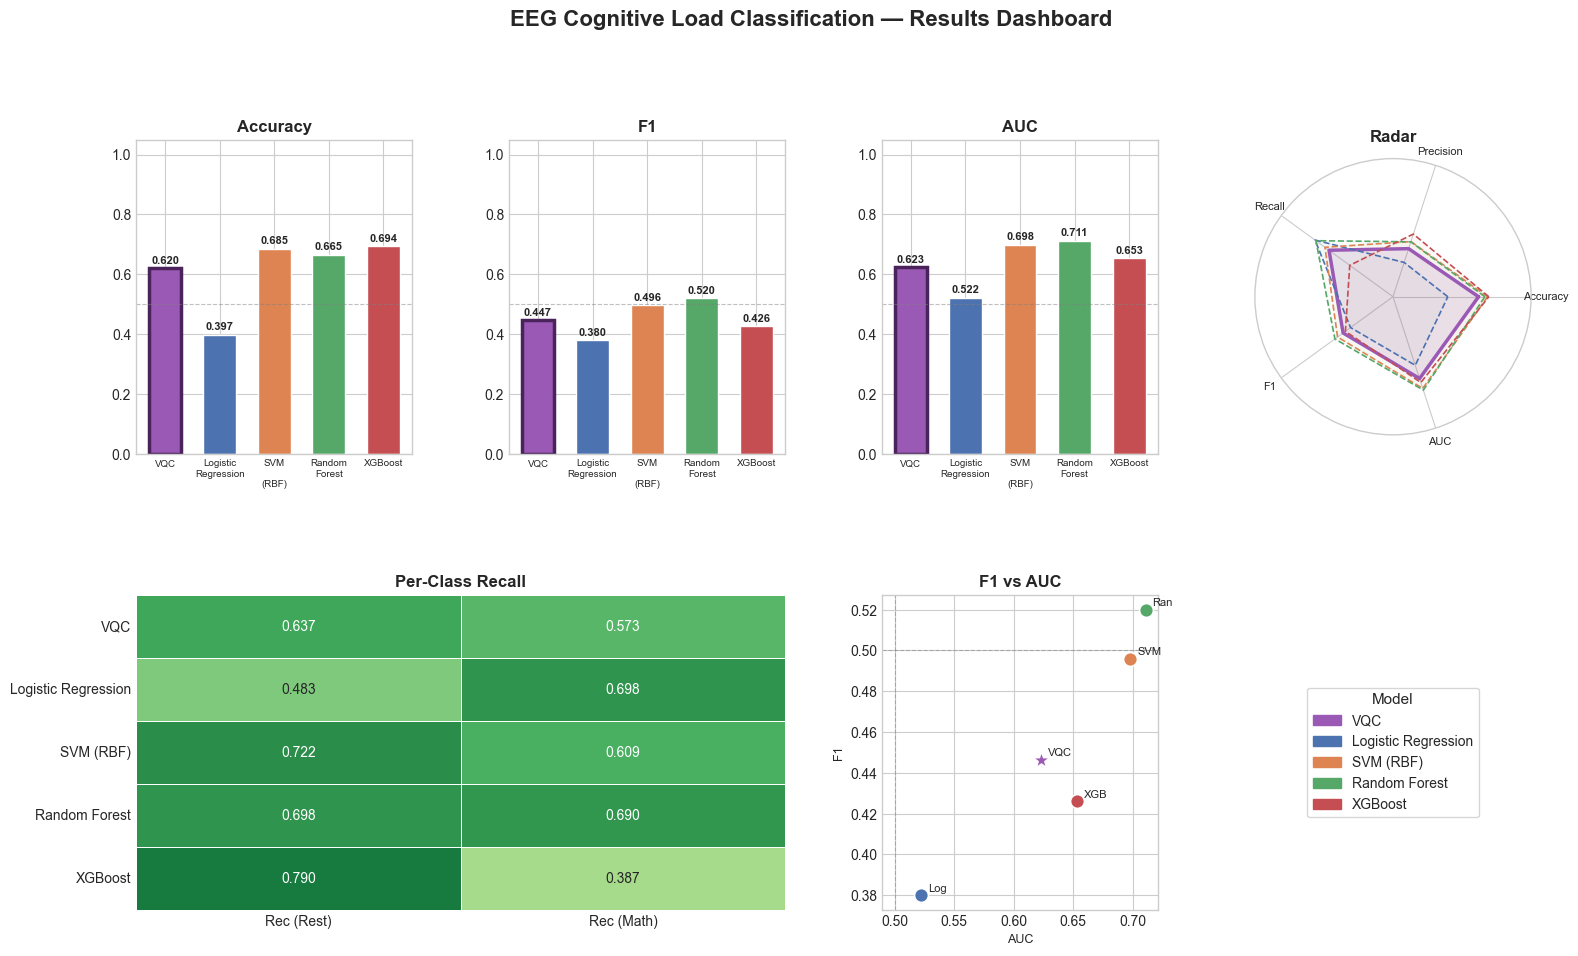

In [11]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

metrics_bar = ['Accuracy', 'F1', 'AUC']
colors_bar  = [PALETTE[n] for n in MODEL_ORDER]
x = np.arange(len(MODEL_ORDER))

# Top row: Accuracy, F1, AUC bar charts
for col_idx, metric in enumerate(metrics_bar):
    ax = fig.add_subplot(gs[0, col_idx])
    vals = [RESULTS[n][metric] for n in MODEL_ORDER]
    bars = ax.bar(x, vals, color=colors_bar, edgecolor='white', width=0.6)
    vqc_i = MODEL_ORDER.index('VQC')
    bars[vqc_i].set_edgecolor('#4A235A'); bars[vqc_i].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n').replace('(', '\n(') for n in MODEL_ORDER],
                       fontsize=7)
    ax.set_ylim(0, 1.05); ax.set_title(metric, fontweight='bold')

# Top-right: radar
ax_r = fig.add_subplot(gs[0, 3], polar=True)
metrics_r = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
angles_r  = np.linspace(0, 2*np.pi, len(metrics_r), endpoint=False).tolist()
angles_r += angles_r[:1]
for name in MODEL_ORDER:
    vals = [RESULTS[name][m] for m in metrics_r] + [RESULTS[name][metrics_r[0]]]
    lw   = 2.5 if name == 'VQC' else 1.2
    ax_r.plot(angles_r, vals, color=PALETTE[name], lw=lw,
              ls='-' if name=='VQC' else '--', label=name)
    ax_r.fill(angles_r, vals, color=PALETTE[name],
              alpha=0.12 if name=='VQC' else 0.03)
ax_r.set_thetagrids(np.degrees(angles_r[:-1]), metrics_r, fontsize=8)
ax_r.set_ylim(0, 1); ax_r.set_yticks([])
ax_r.set_title('Radar', fontweight='bold', pad=12)

# Bottom row: per-class recall heatmap + precision-recall scatter + AUC bar
ax_pc = fig.add_subplot(gs[1, :2])
recall_pc = pd.DataFrame({
    n: {'Rec (Rest)': PC_RESULTS[n][1], 'Rec (Math)': PC_RESULTS[n][4]}
    for n in MODEL_ORDER
}).T
sns.heatmap(recall_pc, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1,
            ax=ax_pc, linewidths=0.5, cbar=False)
ax_pc.set_title('Per-Class Recall', fontweight='bold')
ax_pc.tick_params(axis='y', rotation=0)

# Bottom: F1 vs AUC scatter
ax_sc = fig.add_subplot(gs[1, 2])
for name in MODEL_ORDER:
    ax_sc.scatter(RESULTS[name]['AUC'], RESULTS[name]['F1'],
                  color=PALETTE[name], s=180 if name=='VQC' else 100,
                  marker='*' if name=='VQC' else 'o',
                  edgecolors='white', linewidths=1.2, zorder=5)
    ax_sc.annotate(name[:3], (RESULTS[name]['AUC'], RESULTS[name]['F1']),
                   textcoords='offset points', xytext=(5, 3), fontsize=8)
ax_sc.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
ax_sc.axvline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
ax_sc.set_xlabel('AUC', fontsize=9); ax_sc.set_ylabel('F1', fontsize=9)
ax_sc.set_title('F1 vs AUC', fontweight='bold')

# Bottom: legend
ax_leg = fig.add_subplot(gs[1, 3])
ax_leg.axis('off')
handles = [mpatches.Patch(color=PALETTE[n], label=n) for n in MODEL_ORDER]
ax_leg.legend(handles=handles, loc='center', fontsize=10, frameon=True,
              title='Model', title_fontsize=11)

fig.suptitle('EEG Cognitive Load Classification — Results Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

## 9. Summary

### Key Findings

**Random Forest achieves the best overall performance** (F1=0.520, AUC=0.711, recording-level accuracy=0.812), followed closely by SVM (RBF) (F1=0.496, AUC=0.698). Both ensemble/kernel methods comfortably outperform the quantum model on this dataset.

**The VQC surpasses random chance** (AUC=0.623 vs 0.500 baseline) and correctly identifies over half of mental-math epochs (recall=0.573), demonstrating that quantum-classical hybrid circuits can genuinely learn from EEG spectral features. However, with only 60 trainable parameters the circuit lacks the capacity to match classical models trained on the same 3 413 epochs.

### Model-by-Model Analysis

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Random Forest** | Best F1 & AUC; strong recording-level (0.812) | Moderate epoch accuracy (0.665) |
| **SVM (RBF)** | Balanced precision/recall; good AUC (0.698) | Slightly below RF on all headline metrics |
| **XGBoost** | Highest epoch accuracy (0.694); best Rest F1 (0.784) | Very low Mental Math recall (0.387) — misses most cognitive load events |
| **VQC** | Above-random AUC; reasonable recall; minimal parameters (60) | Low precision (0.366); barren-plateau optimisation limits convergence |
| **Logistic Regression** | Highest Mental Math recall (0.698) | Lowest AUC and epoch accuracy; linear boundary too simple |

### Why Classical ML Wins Here

1. **Capacity mismatch** — RF and XGBoost have millions of effective parameters through ensemble averaging; the VQC has 60.
2. **Barren plateaus** — VQC gradient magnitudes shrink with circuit depth, slowing convergence relative to classical backprop.
3. **Feature geometry** — Hand-crafted EEG spectral features form axis-aligned clusters that decision-tree splits exploit directly.
4. **Inter-subject variability** — 8 test subjects differ in spectral profiles; a 60-parameter model cannot memorise per-subject offsets.

### When Would VQC Be Competitive?

- **High-dimensional quantum data** with intrinsic entanglement structure
- **>20 qubits** where the exponentially large Hilbert space provides genuine representational advantage
- **Quantum kernel advantage** — provably harder-to-compute kernels for specific problem geometries
- **Resource-constrained hardware** — 60-parameter model is orders of magnitude smaller than RF; relevant if model size on quantum chips is the bottleneck

### Conclusion

This study confirms that EEG-based cognitive load classification is feasible from five spectral features, with classical ensemble methods (Random Forest, SVM) achieving the strongest performance. The Variational Quantum Classifier demonstrates proof-of-concept quantum learning from real biosignal data, but near-term quantum advantage for compact tabular EEG features remains beyond current hardware scale. Future work with higher qubit counts, noise-resilient circuits, or quantum-native feature maps may close this gap.